In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_trips

Path to dataset files: C:\Users\jinfe\.cache\kagglehub\datasets\yogape\logistics-operations-database\versions\1


In [2]:
# Set the default figure size
plt.rcParams['figure.figsize'] = (10, 6)
sns.set(color_codes = True)
pd.set_option('display.width', 1200)
pd.set_option('display.max_columns', None)

In [3]:
trips_df = load_trips()
print(trips_df.isnull().sum())

trip_id                     0
load_id                     0
driver_id                1714
truck_id                 1672
trailer_id               1680
dispatch_date               0
actual_distance_miles       0
actual_duration_hours       0
fuel_gallons_used           0
average_mpg                 0
idle_time_hours             0
trip_status                 0
dtype: int64


In [4]:
trips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trip_id                85410 non-null  object 
 1   load_id                85410 non-null  object 
 2   driver_id              83696 non-null  object 
 3   truck_id               83738 non-null  object 
 4   trailer_id             83730 non-null  object 
 5   dispatch_date          85410 non-null  object 
 6   actual_distance_miles  85410 non-null  int64  
 7   actual_duration_hours  85410 non-null  float64
 8   fuel_gallons_used      85410 non-null  float64
 9   average_mpg            85410 non-null  float64
 10  idle_time_hours        85410 non-null  float64
 11  trip_status            85410 non-null  object 
dtypes: float64(4), int64(1), object(7)
memory usage: 7.8+ MB


In [5]:
trips_df['dispatch_date']=pd.to_datetime(trips_df['dispatch_date'])
trips_df['year']=pd.to_datetime(trips_df['dispatch_date']).dt.year
trips_df['month_year']=pd.to_datetime(trips_df['dispatch_date']).dt.to_period('M')

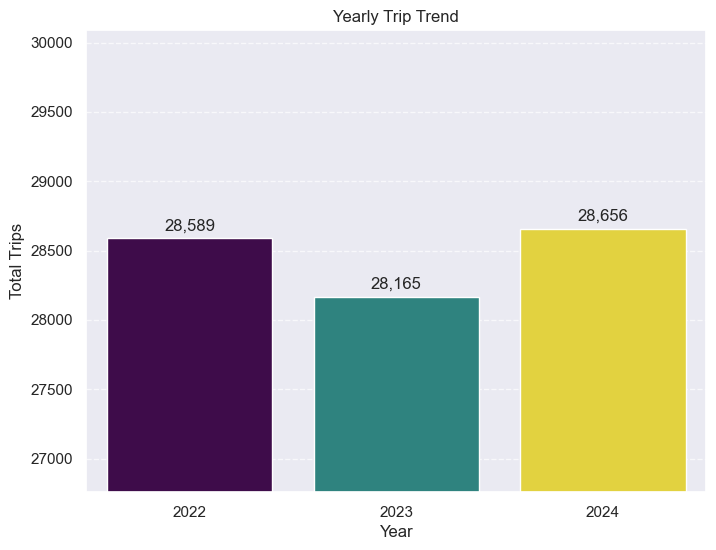

In [6]:
yearly_trips = (
    trips_df.groupby('year')['trip_id']
    .count()
    .reset_index()
)

# 2. Create the bar chart
plt.figure(figsize=(8, 6))

# Use hue='year' and legend=False to avoid the FutureWarning
ax = sns.barplot(
    data=yearly_trips, 
    x='year', 
    y='trip_id', 
    hue='year', 
    palette='viridis', 
    legend=False
)

# 3. THE TRICK: Zoom in on the Y-axis to make differences obvious
# We set the bottom of the axis just below your lowest trip count
min_trips = yearly_trips['trip_id'].min()
max_trips = yearly_trips['trip_id'].max()
plt.ylim(min_trips * 0.95, max_trips * 1.05) 

# 4. Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Yearly Trip Trend')
plt.xlabel('Year')
plt.ylabel('Total Trips')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

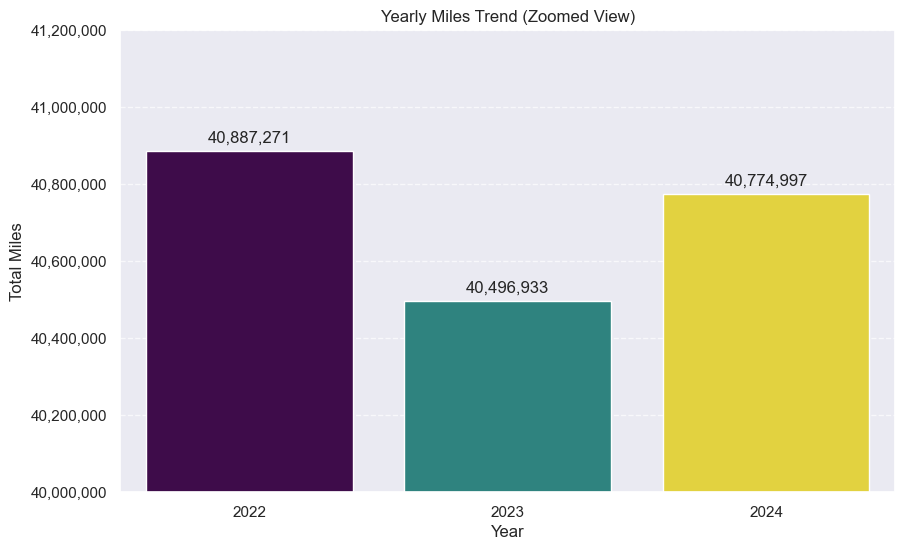

In [7]:
yearly_miles = (
    trips_df.groupby('year')['actual_distance_miles']
    .sum()
    .reset_index()
)

# 2. Create the bar chart
plt.figure(figsize=(10, 6))

# Use hue='year' and legend=False to follow Seaborn best practices
ax = sns.barplot(
    data=yearly_miles, 
    x='year', 
    y='actual_distance_miles', 
    hue='year', 
    palette='viridis', 
    legend=False
)

# 3. THE TRICK: Zoom in on the Y-axis to see the small differences in mileage
# Mileage stays between 40.5M and 40.9M, so we zoom into that range
plt.ylim(40_000_000, 41_200_000) 

# 4. Format the Y-axis for readability (commas instead of scientific notation)
plt.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 5. Add data labels on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Yearly Miles Trend (Zoomed View)')
plt.xlabel('Year')
plt.ylabel('Total Miles')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
print(trips_df.head())

        trip_id       load_id driver_id  truck_id trailer_id dispatch_date  actual_distance_miles  actual_duration_hours  fuel_gallons_used  average_mpg  idle_time_hours trip_status  year month_year
0  TRIP00000001  LOAD00000001  DRV00117  TRK00035   TRL00167    2022-01-01                   1314                   26.2              183.8         7.15              3.5   Completed  2022    2022-01
1  TRIP00000002  LOAD00000002  DRV00141  TRK00108   TRL00082    2022-01-01                    515                    8.6               93.6         5.50              8.3   Completed  2022    2022-01
2  TRIP00000003  LOAD00000003  DRV00032  TRK00031   TRL00138    2022-01-01                   2509                   45.0              339.1         7.40             12.0   Completed  2022    2022-01
3  TRIP00000004  LOAD00000004  DRV00083  TRK00105   TRL00018    2022-01-01                    717                   11.1              110.3         6.50              9.6   Completed  2022    2022-01
4  TR